# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Ahlam Idris

**Date:** 09/09/2026

In [ ]:
# Your Phase 1 solution to the problem goes here.

#q1 
Upload image from Ipad of the calculations and upload to GitHub repo

![Alternative Text](path/to/image (A2 HW).pdf)

#q2 
This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, .groupby([vars]).count() and .groupby([vars]).sum() will be especially useful to tally the number of occurrences and sum the values of those occurrences.

In [69]:
pip install numpy


[notice] A new release of pip is available: 23.1.2 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [70]:
pip install seaborn


[notice] A new release of pip is available: 23.1.2 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [71]:
pip install matplotlib


[notice] A new release of pip is available: 23.1.2 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [108]:
pip install pandas


[notice] A new release of pip is available: 23.1.2 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [109]:
pip install xlrd


[notice] A new release of pip is available: 23.1.2 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [110]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [111]:
ForeignGifts = pd.read_csv('ForeignGifts_edu.csv')

In [112]:
print("ForeignGifts.shape:")
print(ForeignGifts.shape, '\n')

print("ForeignGifts.dtypes:")
print(ForeignGifts.dtypes, '\n')

ForeignGifts.head(5)

ForeignGifts.shape:
(28221, 10) 

ForeignGifts.dtypes:
ID                            int64
OPEID                         int64
Institution Name                str
City                            str
State                           str
Foreign Gift Received Date    int64
Foreign Gift Amount           int64
Gift Type                       str
Country of Giftor               str
Giftor Name                     str
dtype: object 



,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


In [113]:
print("ForeignGifts.shape:")
print(ForeignGifts.shape, '\n')
print("ForeignGifts.dtypes:")
print(ForeignGifts.dtypes, '\n')
ForeignGifts.head()

ForeignGifts.shape:
(28221, 10) 

ForeignGifts.dtypes:
ID                            int64
OPEID                         int64
Institution Name                str
City                            str
State                           str
Foreign Gift Received Date    int64
Foreign Gift Amount           int64
Gift Type                       str
Country of Giftor               str
Giftor Name                     str
dtype: object 



,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


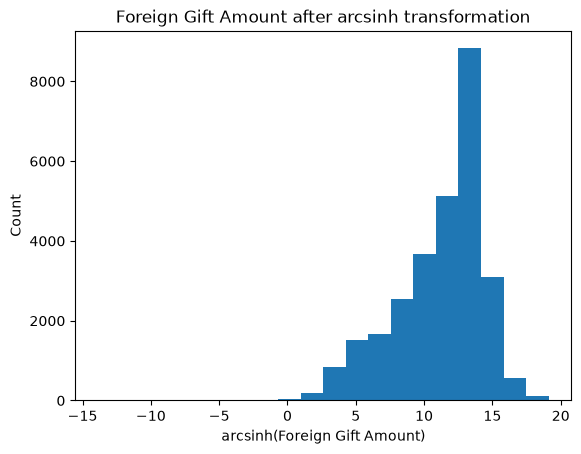

In [114]:
ForeignGifts["Foreign Gift Amount_arcsinh"] = np.arcsinh(ForeignGifts["Foreign Gift Amount"])
ForeignGifts["Foreign Gift Amount_arcsinh"].hist(bins=20, grid=False)
plt.title("Foreign Gift Amount after arcsinh transformation")
plt.xlabel("arcsinh(Foreign Gift Amount)")
plt.ylabel("Count")
plt.show()

Describe the variable and findings

The foreign gift amount is heavily right skewed according to the histogram and most of the gifts are roughly small but there are a few large ones that expand the range. After doing the arcsinh transformation to better interpret the graph, and the data looks about bell-shaped with peaks around gifts in the hundreds of thousands to a few million dollars. After the transformation, the values look more evenly spread out/distributed with a majority of the gifts clustering around a few hundred thousand dollars

In [115]:
x = ForeignGifts["Gift Type"].dropna().sample(28221, random_state=10).to_numpy()

In [116]:
print (x)

['Contract' 'Monetary Gift' 'Contract' ... 'Monetary Gift' 'Monetary Gift'
 'Contract']


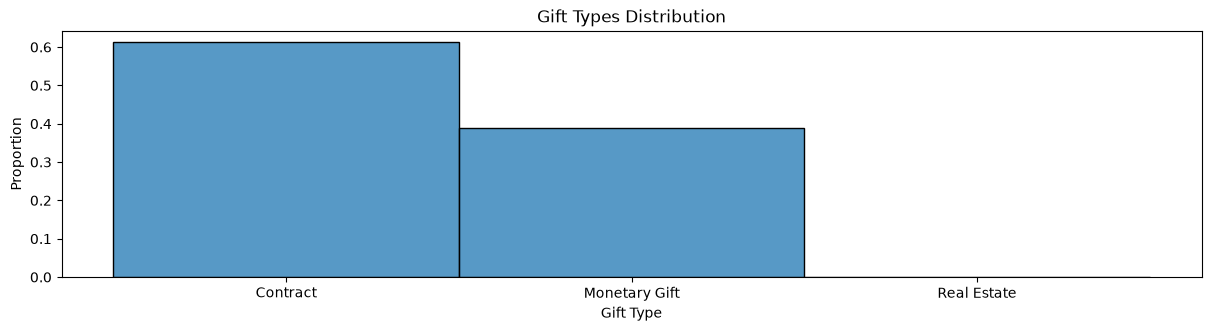

In [117]:
fig, ax = plt.subplots(1, 1, figsize=(12, 3.2), layout="constrained")
sns.histplot(x=x, bins=3, stat="proportion", ax=ax)
ax.set(title="Gift Types Distribution", xlabel="Gift Type")
plt.show()

What proportion of the gifts are contracts, real estate, and monetary gifts?

Contracts make up just about 60/61% of all gifts, Monetary Gifts make up roughly 39% and based on counting each category and dividing by the total number of gifts (28,221). Real Estate gifts seem to be very rare and aren't fully displayed on the histogram but make up about 11 gifts or below .1% of the dataset. 

Create kernel density plot of the log of Foreign Gift Amount

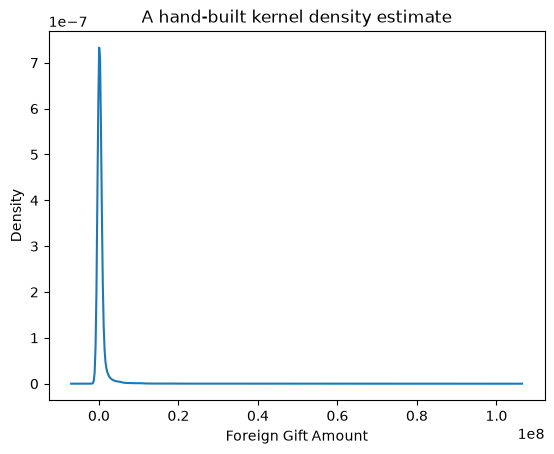

In [118]:
x = pd.to_numeric(ForeignGifts['Foreign Gift Amount'], errors='coerce').dropna().to_numpy()
N = len(x)
sample_sd = np.std(x, ddof=1)
h_s = 1.06 * sample_sd * N**(-1 / 5)

grid = np.linspace(x.min() - 2 * sample_sd, x.max() + 2 * sample_sd, 500)

def normal_kernel(center, bandwidth):
    z = (grid - center) / bandwidth
    return np.exp(-(z**2) / 2) / (bandwidth * np.sqrt(2 * np.pi))

kde = sum(normal_kernel(value, h_s) for value in x) / N
ax = sns.lineplot(x=grid, y=kde)
ax.set(title="A hand-built kernel density estimate", xlabel="Foreign Gift Amount", ylabel="Density")
plt.show()

take the log of the data for the kernel data

In [119]:
ForeignGifts_pos=ForeignGifts[ForeignGifts['Foreign Gift Amount'] > 0]

In [120]:
ForeignGifts_pos['log_amount'] = np.log(ForeignGifts_pos['Foreign Gift Amount'])

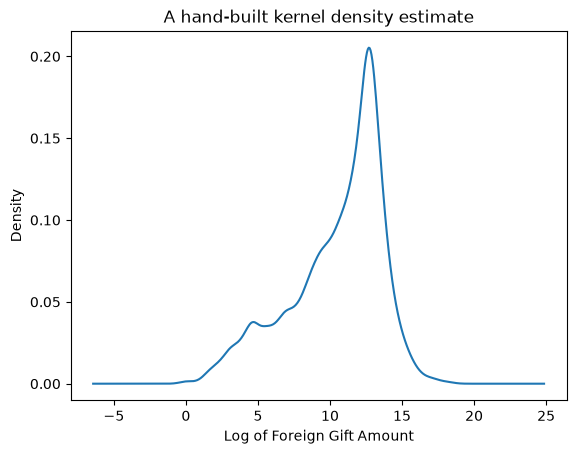

In [122]:
x=pd.to_numeric(ForeignGifts_pos['log_amount'], errors='coerce').dropna().to_numpy()
sample_sd = np.std(x, ddof=1)
h_s = 1.06 * sample_sd * N**(-1 / 5)
grid = np.linspace(x.min() - 2 * sample_sd, x.max() + 2 * sample_sd, 500)

def normal_kernel(center, bandwidth):
    z = (grid - center) / bandwidth
    return np.exp(-(z**2) / 2) / (bandwidth * np.sqrt(2 * np.pi))
kde = sum(normal_kernel(value, h_s) for value in x) / N
ax = sns.lineplot(x=grid, y=kde)
ax.set(title="A hand-built kernel density estimate", xlabel="Log of Foreign Gift Amount", ylabel="Density")
plt.show()

Create a kernel density plot of the log of Foreign Gift Amount conditional on gift type

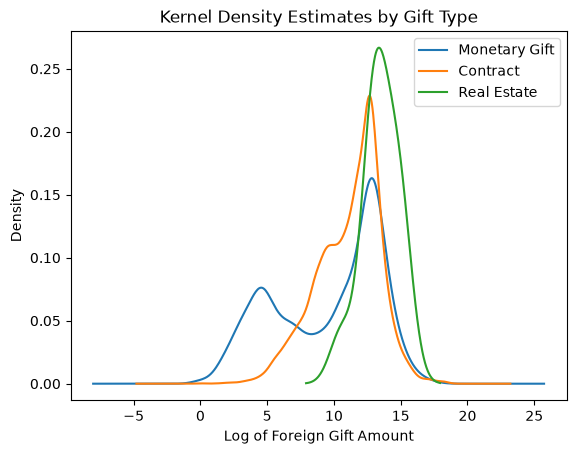

In [123]:
gift_types=ForeignGifts_pos['Gift Type'].dropna().unique()
fig, ax=plt.subplots()
for gt in gift_types:
    x=pd.to_numeric(ForeignGifts_pos[ForeignGifts_pos['Gift Type']==gt]['log_amount'], errors='coerce').dropna().to_numpy()
    N = len(x)
    sample_sd = np.std(x, ddof=1)
    h_s = 1.06 * sample_sd * N**(-1 / 5)
    grid = np.linspace(x.min() - 2 * sample_sd, x.max() + 2 * sample_sd, 500)
    def normal_kernel(center, bandwidth):
        z = (grid - center) / bandwidth
        return np.exp(-(z**2) / 2) / (bandwidth * np.sqrt(2 * np.pi))
    kde = sum(normal_kernel(value, h_s) for value in x) / N
    sns.lineplot(x=grid, y=kde, ax=ax, label=gt)
ax.set(title="Kernel Density Estimates by Gift Type", xlabel="Log of Foreign Gift Amount", ylabel="Density")
plt.show()

Do you notice any patterns in the kernel density plot?

All of the graphs have a peak around the same range/cluster which is a few hundred thousand to a few million dollars. Real estate gifts tend to be slightly larger on average. I was surprised about the curve for monetary gifts because they have a second and smaller bunching which demonstrates that a lot of small cash donations exist alongside the larger ones. The bottom two graphs are left skewed, while the first graph is right skewed. 

In [125]:
top15_by_count=ForeignGifts.groupby('Country of Giftor')['ID'].count().sort_values(ascending=False).head(15)

In [126]:
print(top15_by_count)

Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN              381
Name: ID, dtype: int64


In [127]:
top15_by_amount= ForeignGifts.groupby('Country of Giftor')['Foreign Gift Amount'].sum().sort_values(ascending=False).head(15)
print(top15_by_amount)

Country of Giftor
QATAR                   2706240869
ENGLAND                 1464906771
CHINA                   1237952112
SAUDI ARABIA            1065205930
BERMUDA                  899593972
CANADA                   898160656
HONG KONG                887402529
JAPAN                    655954776
SWITZERLAND              619899445
INDIA                    539556490
GERMANY                  442475605
UNITED ARAB EMIRATES     431396357
FRANCE                   405839396
SINGAPORE                401157692
AUSTRALIA                248409202
Name: Foreign Gift Amount, dtype: int64


What are the top 15 countries in terms of the number of gifts? 

The top 15 countries in terms of the number of gifts are England, China, Canada, Japan, Switzerland, Saudi Arabia, France, Germany, Hong Kong, South Korea, Qatar, The Netherlands, Korea, India, and Taiwan.

What are the top 15 countries in terms of the amount given?

The top 15 countries in terms of the amount given are Qatar, England, China, Saudi Arabia, Bermuda, Canada, Hong Kong, Japan, Switzerland, India, Germany, United Arab Emirates, France, Singapore, Australia

In [128]:
top15_giftors= ForeignGifts.groupby('Giftor Name')['Foreign Gift Amount'].sum().sort_values(ascending=False).head(15)
print(top15_giftors)

Giftor Name
Qatar Foundation                       1166503744
Qatar Foundation/Qatar National Res     796197000
Qatar Foundation for Education          373945215
Anonymous                               338793629
Saudi Arabian Cultural Mission          275221475
HCL                                     190000000
Church of Jesus Christ of LDS           185203715
Emirates Institute for Advanced Sc      170641244
QIC                                     148355497
Anonymous #9                             96334996
Qatar National Research Fund             79021705
Government of Saudi Arabia               75192434
Contracting Party                        69996984
CMKL University                          67700000
Royal Embassy of Saudi Arabia            67062486
Name: Foreign Gift Amount, dtype: int64


Which giftors provide the most money, in total?

The giftors that provide the most money in total are The Qatar Foundation, Qatar Foundation/Qatar National Res, Qatar Foundation for Education, Anonymous, Saudi Arabian Cultural Mission, HCL, Church of Jesus Christ of LDS, Emirates Institute for Advanced Sc, QIC, Anonymous #9, Qatar National Research Fund, Government of Saudi Arabia, Contracting Party, CMKL Uniiversity, Royal Embassy of Saudi Arabia.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]